# データ構造

                    ┌────────────────────┐
                    │   Teams.csv        │
                    │  (TeamID, TeamName)│
                    └─────────┬──────────┘
                              │
                              │
                    ┌─────────▼──────────┐
                    │   Seasons.csv       │
                    │   (Season情報)      │
                    └─────────┬──────────┘
                              │
                              │
            ┌─────────────────▼─────────────────┐
            │        RegularSeasonCompactResults │
            │        RegularSeasonDetailedResults│
            │            (試合結果)              │
            └──────────────┬────────────────────┘
                           │
                           │
                ┌──────────▼──────────┐
                │  Game-level table   │
                │   (試合ベース)      │
                └──────────┬──────────┘
                           │
                           │ 展開
                           ▼
                ┌─────────────────────┐
                │   team_games table  │
                │  (チーム視点)       │
                │                     │
                │ 1試合 = 2行         │
                │ TeamA perspective   │
                │ TeamB perspective   │
                └──────────┬──────────┘
                           │
                           │
        ┌──────────────────▼───────────────────┐
        │        Feature Engineering            │
        │                                       │
        │ ・Rolling stats                       │
        │ ・Seed                                │
        │ ・Elo                                 │
        │ ・Conference strength                 │
        │ ・Home advantage                      │
        └──────────────────┬───────────────────┘
                           │
                           ▼
                ┌─────────────────────┐
                │   training dataset  │
                │  (matchup table)    │
                │ Team1 vs Team2      │
                └─────────────────────┘

設計思想

RAW CSV
 ↓
team_games  ← 今ここ
 ↓
Team Season Features（チーム強さ）
 ↓
Matchup Dataset（試合予測用）
 ↓
Model

# データ作成

## teams_games

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

# ==============================
# load data
# ==============================

m_rs = pd.read_csv("../Data/MRegularSeasonDetailedResults.csv")
w_rs = pd.read_csv("../Data/WRegularSeasonDetailedResults.csv")

m_tr = pd.read_csv("../Data/MNCAATourneyDetailedResults.csv")
w_tr = pd.read_csv("../Data/WNCAATourneyDetailedResults.csv")


# ==============================
# metadata
# ==============================

m_rs["Gender"] = "M"
w_rs["Gender"] = "W"
m_tr["Gender"] = "M"
w_tr["Gender"] = "W"

m_rs["GameType"] = "Regular"
w_rs["GameType"] = "Regular"
m_tr["GameType"] = "Tournament"
w_tr["GameType"] = "Tournament"


# ==============================
# combine games
# ==============================

games = pd.concat(
    [m_rs, w_rs, m_tr, w_tr],
    ignore_index=True
)


# ==============================
# winner perspective
# ==============================

w = pd.DataFrame({

    "Season": games["Season"],
    "DayNum": games["DayNum"],
    "Gender": games["Gender"],
    "GameType": games["GameType"],

    "TeamID": games["WTeamID"],
    "OppTeamID": games["LTeamID"],

    "TeamScore": games["WScore"],
    "OppScore": games["LScore"],

    "Win": 1,
    "Loc": games["WLoc"],
    "NumOT": games["NumOT"],

    "FGM": games["WFGM"],
    "FGA": games["WFGA"],
    "FGM3": games["WFGM3"],
    "FGA3": games["WFGA3"],
    "FTM": games["WFTM"],
    "FTA": games["WFTA"],
    "OR": games["WOR"],
    "DR": games["WDR"],
    "Ast": games["WAst"],
    "TO": games["WTO"],
    "Stl": games["WStl"],
    "Blk": games["WBlk"],
    "PF": games["WPF"],

    "OppFGM": games["LFGM"],
    "OppFGA": games["LFGA"],
    "OppFGM3": games["LFGM3"],
    "OppFGA3": games["LFGA3"],
    "OppFTM": games["LFTM"],
    "OppFTA": games["LFTA"],
    "OppOR": games["LOR"],
    "OppDR": games["LDR"],
    "OppAst": games["LAst"],
    "OppTO": games["LTO"],
    "OppStl": games["LStl"],
    "OppBlk": games["LBlk"],
    "OppPF": games["LPF"]

})


# ==============================
# loser perspective
# ==============================

loc_flip = {"H": "A", "A": "H", "N": "N"}

l = pd.DataFrame({

    "Season": games["Season"],
    "DayNum": games["DayNum"],
    "Gender": games["Gender"],
    "GameType": games["GameType"],

    "TeamID": games["LTeamID"],
    "OppTeamID": games["WTeamID"],

    "TeamScore": games["LScore"],
    "OppScore": games["WScore"],

    "Win": 0,
    "Loc": games["WLoc"].map(loc_flip),
    "NumOT": games["NumOT"],

    "FGM": games["LFGM"],
    "FGA": games["LFGA"],
    "FGM3": games["LFGM3"],
    "FGA3": games["LFGA3"],
    "FTM": games["LFTM"],
    "FTA": games["LFTA"],
    "OR": games["LOR"],
    "DR": games["LDR"],
    "Ast": games["LAst"],
    "TO": games["LTO"],
    "Stl": games["LStl"],
    "Blk": games["LBlk"],
    "PF": games["LPF"],

    "OppFGM": games["WFGM"],
    "OppFGA": games["WFGA"],
    "OppFGM3": games["WFGM3"],
    "OppFGA3": games["WFGA3"],
    "OppFTM": games["WFTM"],
    "OppFTA": games["WFTA"],
    "OppOR": games["WOR"],
    "OppDR": games["WDR"],
    "OppAst": games["WAst"],
    "OppTO": games["WTO"],
    "OppStl": games["WStl"],
    "OppBlk": games["WBlk"],
    "OppPF": games["WPF"]

})


# ==============================
# team_games
# ==============================

team_games = pd.concat([w, l], ignore_index=True)


# ==============================
# derived features
# ==============================

team_games["ScoreDiff"] = (
    team_games["TeamScore"] - team_games["OppScore"]
)

team_games["Poss"] = (
    team_games["FGA"]
    - team_games["OR"]
    + team_games["TO"]
    + 0.44 * team_games["FTA"]
)

team_games["OppPoss"] = (
    team_games["OppFGA"]
    - team_games["OppOR"]
    + team_games["OppTO"]
    + 0.44 * team_games["OppFTA"]
)

team_games["OffRating"] = (
    100 * team_games["TeamScore"] / team_games["Poss"]
)

team_games["DefRating"] = (
    100 * team_games["OppScore"] / team_games["OppPoss"]
)


# ==============================
# sort
# ==============================

team_games = team_games.sort_values(
    ["Season", "TeamID", "DayNum"]
).reset_index(drop=True)


print(team_games.shape)
team_games.head()

(426428, 42)


,Season,DayNum,Gender,GameType,TeamID,OppTeamID,TeamScore,OppScore,Win,Loc,...,OppAst,OppTO,OppStl,OppBlk,OppPF,ScoreDiff,Poss,OppPoss,OffRating,DefRating
0,2003,19,M,Regular,1102,1257,47,65,0,A,...,12,14,8,4,23,-18,61.04,60.80,76.998689,106.907895
1,2003,22,M,Regular,1102,1391,72,43,1,H,...,5,11,5,0,12,29,53.08,53.60,135.644310,80.223881
2,2003,25,M,Regular,1102,1117,57,52,1,A,...,8,8,3,0,19,5,52.68,53.24,108.200456,97.670924
3,2003,27,M,Regular,1102,1399,47,60,0,A,...,13,14,4,1,13,-13,51.28,49.80,91.653666,120.481928
4,2003,31,M,Regular,1102,1410,65,44,1,H,...,7,13,3,0,13,21,45.08,45.96,144.188110,95.735422


### EDA

In [7]:
team_games.describe().T

,count,mean,std,min,25%,50%,75%,max
Season,421380.0,2015.952926,6.275846,2003.000000,2011.000000,2016.000000,2021.000000,2026.000000
DayNum,421380.0,70.328506,36.653703,0.000000,37.000000,73.000000,101.000000,155.000000
TeamID,421380.0,2106.864108,989.512615,1101.000000,1258.000000,1412.000000,3247.000000,3481.000000
OppTeamID,421380.0,2106.864108,989.512615,1101.000000,1258.000000,1412.000000,3247.000000,3481.000000
TeamScore,421380.0,67.810689,13.166553,11.000000,59.000000,67.000000,76.000000,149.000000
OppScore,421380.0,67.810689,13.166553,11.000000,59.000000,67.000000,76.000000,149.000000
Win,421380.0,0.500000,0.500001,0.000000,0.000000,0.500000,1.000000,1.000000
NumOT,421380.0,0.061446,0.286224,0.000000,0.000000,0.000000,0.000000,6.000000
FGM,421380.0,24.144383,5.114500,3.000000,21.000000,24.000000,27.000000,59.000000
FGA,421380.0,57.250335,7.778563,25.000000,52.000000,57.000000,62.000000,113.000000


In [8]:
team_games["Win"].value_counts(normalize=True)

Win
0    0.5
1    0.5
Name: proportion, dtype: float64

In [9]:
team_games["Loc"].value_counts()

Loc
A    188472
H    188472
N     44436
Name: count, dtype: int64

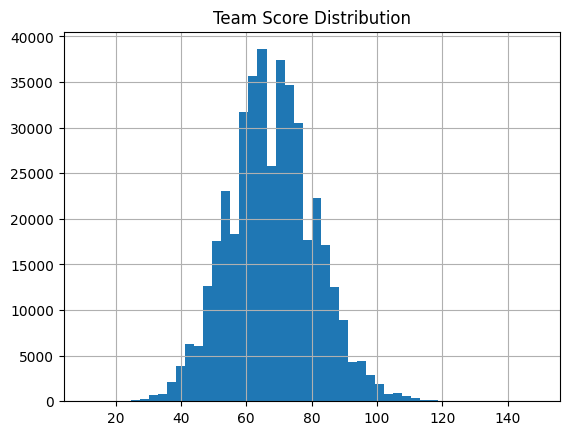

In [10]:
import matplotlib.pyplot as plt

team_games["TeamScore"].hist(bins=50)
plt.title("Team Score Distribution")
plt.show()

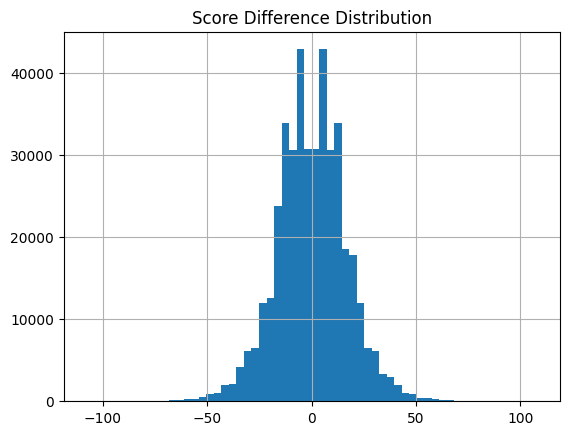

In [11]:
team_games["ScoreDiff"].hist(bins=60)
plt.title("Score Difference Distribution")
plt.show()

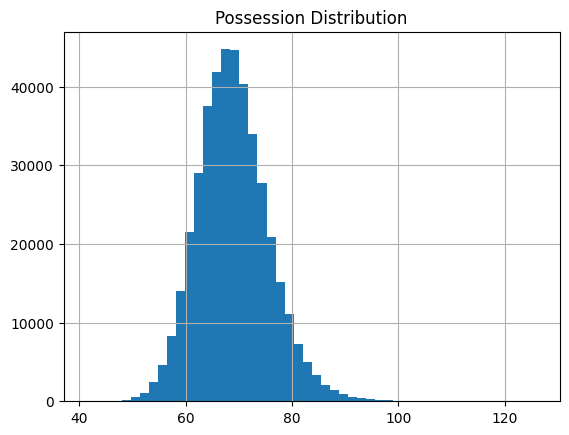

In [12]:
team_games["Poss"].hist(bins=50)
plt.title("Possession Distribution")
plt.show()

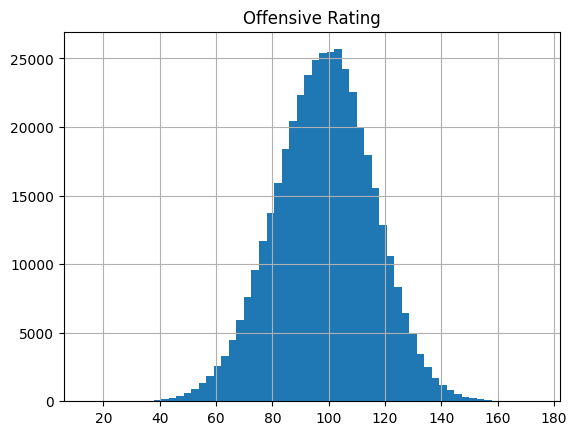

In [13]:
team_games["OffRating"].hist(bins=60)
plt.title("Offensive Rating")
plt.show()

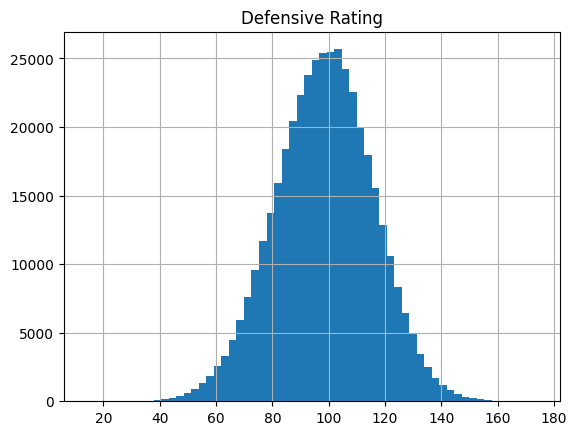

In [14]:
team_games["DefRating"].hist(bins=60)
plt.title("Defensive Rating")
plt.show()

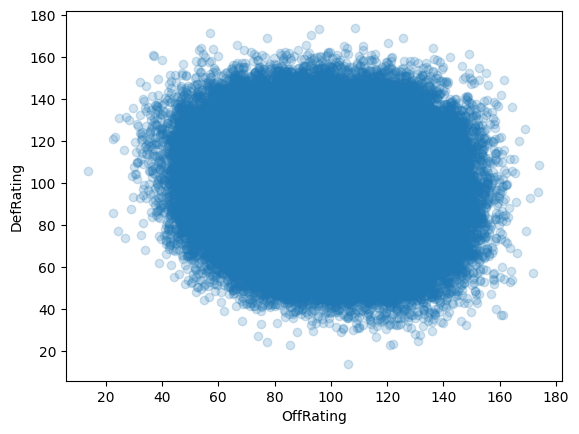

In [15]:
plt.scatter(
    team_games["OffRating"],
    team_games["DefRating"],
    alpha=0.2
)

plt.xlabel("OffRating")
plt.ylabel("DefRating")
plt.show()

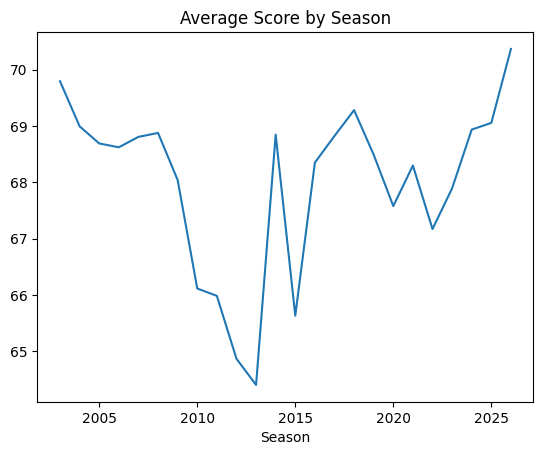

In [18]:
team_games.groupby("Season")["TeamScore"].mean().plot()
plt.title("Average Score by Season")
plt.show()

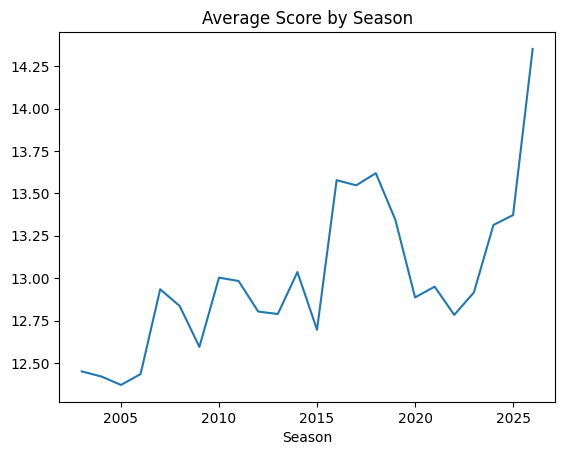

In [17]:
team_games.groupby("Season")["TeamScore"].std().plot()
plt.title("Average Score by Season")
plt.show()

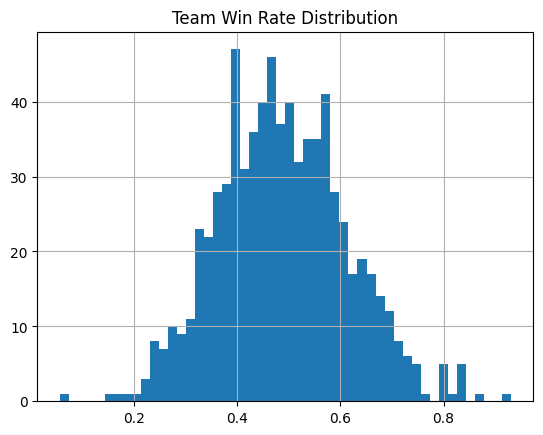

In [19]:
team_games.groupby("TeamID")["Win"].mean().hist(bins=50)
plt.title("Team Win Rate Distribution")
plt.show()

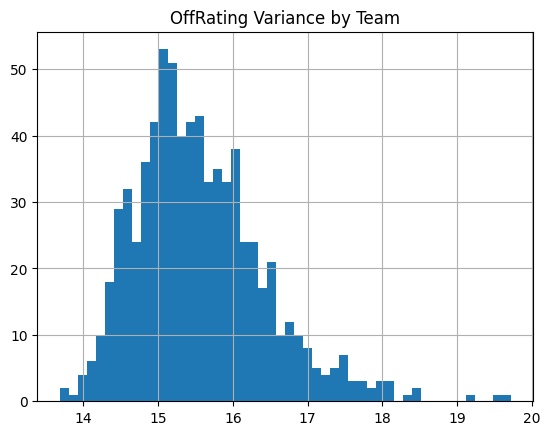

In [22]:
team_games.groupby("TeamID")["OffRating"].std().hist(bins=50)
plt.title("OffRating Variance by Team")
plt.show()

<Axes: xlabel='DayNum'>

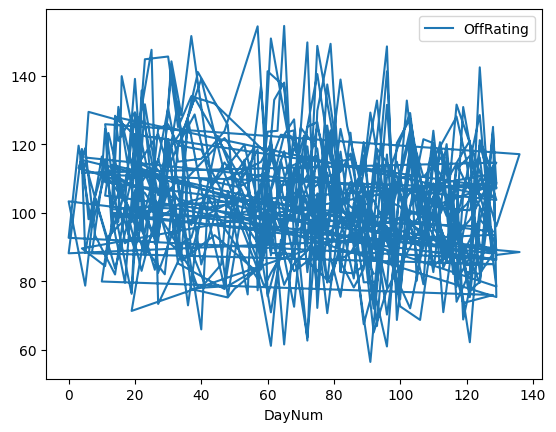

In [23]:
sample_team = team_games["TeamID"].iloc[0]

team_games[
    team_games["TeamID"] == sample_team
].plot(
    x="DayNum",
    y="OffRating"
)

In [24]:
corr = team_games[
[
"TeamScore",
"Poss",
"OffRating",
"DefRating",
"ScoreDiff"
]
].corr()

print(corr)

           TeamScore      Poss  OffRating  DefRating  ScoreDiff
TeamScore   1.000000  0.420070   0.862985  -0.006334   0.629934
Poss        0.420070  1.000000  -0.087603  -0.048322  -0.006853
OffRating   0.862985 -0.087603   1.000000   0.022276   0.690008
DefRating  -0.006334 -0.048322   0.022276   1.000000  -0.690008
ScoreDiff   0.629934 -0.006853   0.690008  -0.690008   1.000000


In [25]:
team_games.groupby("Win")[[
"OffRating",
"DefRating",
"ScoreDiff"
]].mean()

,OffRating,DefRating,ScoreDiff
Win,,,
0,88.721627,108.143048,-13.065888
1,108.143048,88.721627,13.065888


## Team Season Features

In [4]:
"""
01_season_stats.py
==================
INPUT : team_games (DataFrame, 既存)
OUTPUT: ../Data/mart/team_season_stats.csv
"""

import pandas as pd
import numpy as np
from pathlib import Path

MART_DIR = Path("../Data/mart")
MART_DIR.mkdir(parents=True, exist_ok=True)


def build_season_stats(team_games: pd.DataFrame) -> pd.DataFrame:

    # レギュラーシーズンのみ
    df = team_games[team_games["GameType"] == "Regular"].copy()

    group_keys = ["Season", "Gender", "TeamID"]

    grp = df.groupby(group_keys)

    agg = grp.agg(
        games    = ("Win",       "count"),
        wins     = ("Win",       "sum"),
        PTS      = ("TeamScore", "sum"),
        FGM      = ("FGM",       "sum"),
        FGA      = ("FGA",       "sum"),
        FGM3     = ("FGM3",      "sum"),
        FGA3     = ("FGA3",      "sum"),
        FTM      = ("FTM",       "sum"),
        FTA      = ("FTA",       "sum"),
        OR       = ("OR",        "sum"),
        DR       = ("DR",        "sum"),
        Ast      = ("Ast",       "sum"),
        TO       = ("TO",        "sum"),
        Blk      = ("Blk",       "sum"),
        Opp_PTS  = ("OppScore",  "sum"),
        OppOR    = ("OppOR",     "sum"),
        OppDR    = ("OppDR",     "sum"),
        OppTO    = ("OppTO",     "sum"),
        OppFGA   = ("OppFGA",    "sum"),
        OppFGA3  = ("OppFGA3",   "sum"),
    ).reset_index()

    # Possession
    agg["Poss"] = agg["FGA"] - agg["OR"] + agg["TO"] + 0.44 * agg["FTA"]

    # Ratings
    agg["OffRating"] = 100 * agg["PTS"]     / agg["Poss"].replace(0, np.nan)
    agg["DefRating"] = 100 * agg["Opp_PTS"] / agg["Poss"].replace(0, np.nan)
    agg["NetRating"] = agg["OffRating"] - agg["DefRating"]
    agg["Tempo"]     = agg["Poss"] / agg["games"]

    # Shooting
    agg["FGPct"]  = agg["FGM"]  / agg["FGA"].replace(0, np.nan)
    agg["FG3Pct"] = agg["FGM3"] / agg["FGA3"].replace(0, np.nan)
    agg["FTPct"]  = agg["FTM"]  / agg["FTA"].replace(0, np.nan)

    # Other
    agg["RebRate"] = agg["OR"]  / (agg["OR"] + agg["OppDR"]).replace(0, np.nan)
    agg["TORate"]  = agg["TO"]  / agg["Poss"].replace(0, np.nan)
    agg["AstRate"] = agg["Ast"] / agg["FGM"].replace(0, np.nan)
    agg["BlkRate"] = agg["Blk"] / (agg["OppFGA"] - agg["OppFGA3"]).replace(0, np.nan)
    agg["WinRate"] = agg["wins"] / agg["games"]

    cols = group_keys + [
        "games", "wins", "WinRate",
        "Poss", "Tempo",
        "OffRating", "DefRating", "NetRating",
        "FGPct", "FG3Pct", "FTPct",
        "RebRate", "TORate", "AstRate", "BlkRate",
    ]
    return agg[cols].round(4)


# ── 実行 ──────────────────────────────────────
stats = build_season_stats(team_games)
stats.to_csv(MART_DIR / "team_season_stats.csv", index=False)

print(f"✅ team_season_stats: {stats.shape}")
print(stats.head())

✅ team_season_stats: (14311, 18)
   Season Gender  TeamID  games  wins  WinRate     Poss    Tempo  OffRating  \
0    2003      M    1102     28    12   0.4286  1527.76  54.5629   104.9249   
1    2003      M    1103     27    13   0.4815  1892.12  70.0785   112.4136   
2    2003      M    1104     28    17   0.6071  1850.84  66.1014   104.8173   
3    2003      M    1105     26     7   0.2692  1985.92  76.3815    93.9615   
4    2003      M    1106     28    13   0.4643  1883.84  67.2800    94.5409   

   DefRating  NetRating   FGPct  FG3Pct   FTPct  RebRate  TORate  AstRate  \
0   104.4667     0.4582  0.4811  0.3756  0.6514   0.1718  0.2095   0.6791   
1   111.5151     0.8985  0.4861  0.3387  0.7364   0.3073  0.1802   0.5607   
2    98.3337     6.4835  0.4204  0.3201  0.7099   0.3748  0.2010   0.5037   
3   100.3565    -6.3950  0.3958  0.3648  0.7060   0.3385  0.2442   0.5962   
4    94.7533    -0.2123  0.4238  0.3462  0.6464   0.3546  0.2532   0.4985   

   BlkRate  
0   0.0595  
1  

In [8]:
"""
02_elo.py
=========
INPUT : team_games (DataFrame, 既存)
OUTPUT: ../Data/mart/ratings_elo.csv

【データリーク対策】
特徴量として保存するのは「レギュラーシーズン終了直後のElo」。
過去シーズンのトーナメント結果は蓄積してEloに反映させる。
当該シーズンのトーナメント結果は反映しない。

処理順（時系列）:
  S-1 レギュラー → S-1 トーナメント（Eloに反映）
        ↓
  S   レギュラー → ★ ここでSのEloを保存 → S トーナメント（Eloに反映）
        ↓
  S+1 レギュラー → ★ ここでS+1のEloを保存 → ...
"""

import pandas as pd
import numpy as np
from pathlib import Path

MART_DIR = Path("../Data/mart")
MART_DIR.mkdir(parents=True, exist_ok=True)

INIT_ELO     = 1500
K_REGULAR    = 20
K_TOURNEY    = 40
SEASON_CARRY = 0.75


def compute_elo(team_games: pd.DataFrame) -> pd.DataFrame:

    # Win==1 で1行/試合、Regular → Tournament の順に並べる
    df = team_games[team_games["Win"] == 1].copy()
    df["game_order"] = df["GameType"].map({"Regular": 0, "Tournament": 1})
    df = df.sort_values(["Season", "game_order", "DayNum"]).reset_index(drop=True)

    elo = {}  # key: (Gender, TeamID) → rating

    def get_elo(gender, team_id):
        return elo.get((gender, team_id), INIT_ELO)

    def update_elo(gender, a, b, K):
        elo_a = get_elo(gender, a)
        elo_b = get_elo(gender, b)
        exp_a = 1 / (1 + 10 ** ((elo_b - elo_a) / 400))
        elo[(gender, a)] = elo_a + K * (1 - exp_a)
        elo[(gender, b)] = elo_b + K * (0 - (1 - exp_a))

    records = []
    seasons = sorted(df["Season"].unique())

    for i, season in enumerate(seasons):

        # シーズン開始: 前シーズンEloを平均に引き戻す
        if i > 0:
            for key in list(elo.keys()):
                elo[key] = INIT_ELO + SEASON_CARRY * (elo[key] - INIT_ELO)

        season_df = df[df["Season"] == season]
        regular   = season_df[season_df["GameType"] == "Regular"]
        tourney   = season_df[season_df["GameType"] == "Tournament"]

        # ① レギュラーシーズンを処理
        for _, row in regular.iterrows():
            update_elo(row["Gender"], row["TeamID"], row["OppTeamID"], K_REGULAR)

        # ② ★ レギュラーシーズン終了後のEloを保存（トーナメント予測の特徴量）
        all_teams_by_gender = season_df.groupby("Gender").apply(
            lambda g: set(g["TeamID"]) | set(g["OppTeamID"])
        )
        for gender, teams in all_teams_by_gender.items():
            for team_id in teams:
                records.append({
                    "Season": season,
                    "Gender": gender,
                    "TeamID": team_id,
                    "elo":    round(get_elo(gender, team_id), 2),
                })

        # ③ トーナメントを処理（次シーズン以降のEloに蓄積）
        for _, row in tourney.iterrows():
            update_elo(row["Gender"], row["TeamID"], row["OppTeamID"], K_TOURNEY)

    return pd.DataFrame(records)


# ── 実行 ──────────────────────────────────────────
elo_df = compute_elo(team_games)
elo_df.to_csv(MART_DIR / "ratings_elo.csv", index=False)

print(f"✅ ratings_elo: {elo_df.shape}")
print(elo_df.head())

/var/folders/r4/pq0z41zs42ng8hfdd8ttxysh0000gn/T/ipykernel_1374/3884972501.py:71: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  all_teams_by_gender = season_df.groupby("Gender").apply(
/var/folders/r4/pq0z41zs42ng8hfdd8ttxysh0000gn/T/ipykernel_1374/3884972501.py:71: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  all_teams_by_gender = season_df.groupby("Gender").apply(
/var/folders/r4/pq0z41zs42ng8hfdd8ttxysh0000gn/T/i

✅ ratings_elo: (14311, 4)
   Season Gender  TeamID      elo
0    2003      M    1102  1472.08
1    2003      M    1103  1494.26
2    2003      M    1104  1542.27
3    2003      M    1105  1388.15
4    2003      M    1106  1465.72


/var/folders/r4/pq0z41zs42ng8hfdd8ttxysh0000gn/T/ipykernel_1374/3884972501.py:71: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  all_teams_by_gender = season_df.groupby("Gender").apply(


In [9]:
"""
03_massey.py
============
INPUT : team_games (DataFrame, 既存)
OUTPUT: ../Data/mart/ratings_massey.csv

【データリーク対策】
シーズンSのMasseyを計算する際に使うデータ：
  - Season < S の全試合（レギュラー + トーナメント）✅ 過去情報
  - Season = S のレギュラーシーズンのみ              ✅ トーナメント前に確定
  - Season = S のトーナメント                        ❌ 使わない（未来情報）

またSOS（Strength of Schedule）も同じデータで計算する。
"""

import pandas as pd
import numpy as np
from pathlib import Path
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import lsqr

MART_DIR = Path("../Data/mart")
MART_DIR.mkdir(parents=True, exist_ok=True)

SCORE_CAP = 30  # 得点差の上限キャップ


def _massey_ratings(df: pd.DataFrame) -> pd.Series:
    """
    試合データから Massey レーティングを最小二乗法で計算。
    df: Win==1 の行（1行=1試合）
    """
    teams = sorted(set(df["TeamID"]) | set(df["OppTeamID"]))
    n     = len(teams)
    t_idx = {t: i for i, t in enumerate(teams)}
    rows  = len(df)

    M = lil_matrix((rows + 1, n))
    b = np.zeros(rows + 1)

    for i, row in enumerate(df.itertuples()):
        a    = t_idx[row.TeamID]
        b_   = t_idx[row.OppTeamID]
        diff = np.clip(row.TeamScore - row.OppScore, -SCORE_CAP, SCORE_CAP)
        M[i, a]  =  1
        M[i, b_] = -1
        b[i]     = diff

    # 制約: 全レーティング合計 = 0
    M[rows, :] = 1
    b[rows]    = 0

    ratings, *_ = lsqr(M.tocsr(), b)
    return pd.Series(ratings, index=teams)


def compute_massey(team_games: pd.DataFrame) -> pd.DataFrame:

    # Win==1 で1行/試合
    all_games = team_games[team_games["Win"] == 1].copy()

    seasons = sorted(all_games["Season"].unique())
    records = []

    for season in seasons:

        # ★ シーズンSのMassey計算に使うデータ
        #    過去シーズン（レギュラー＋トーナメント）＋ 当該シーズンのレギュラーのみ
        mask = (
            (all_games["Season"] < season) |
            (
                (all_games["Season"] == season) &
                (all_games["GameType"] == "Regular")
            )
        )
        df = all_games[mask]

        if len(df) == 0:
            continue

        for gender, grp in df.groupby("Gender"):
            if len(grp) < 2:
                continue

            ratings = _massey_ratings(grp)

            for team_id, rating in ratings.items():
                records.append({
                    "Season": season,
                    "Gender": gender,
                    "TeamID": team_id,
                    "massey": rating,
                })

    massey_df = pd.DataFrame(records)

    # ── SOS: 当該シーズンのレギュラーの対戦相手の平均 Massey ──
    reg = team_games[team_games["GameType"] == "Regular"].copy()

    opp = massey_df.rename(
        columns={"TeamID": "OppTeamID", "massey": "opp_massey"}
    )
    reg = reg.merge(
        opp[["Season", "Gender", "OppTeamID", "opp_massey"]],
        on=["Season", "Gender", "OppTeamID"],
        how="left"
    )
    sos = (
        reg.groupby(["Season", "Gender", "TeamID"])["opp_massey"]
        .mean()
        .reset_index()
        .rename(columns={"opp_massey": "sos"})
    )
    massey_df = massey_df.merge(sos, on=["Season", "Gender", "TeamID"], how="left")

    return massey_df.round(4)


# ── 実行 ──────────────────────────────────────────
massey_df = compute_massey(team_games)
massey_df.to_csv(MART_DIR / "ratings_massey.csv", index=False)

print(f"✅ ratings_massey: {massey_df.shape}")
print(massey_df.sort_values("massey", ascending=False).head(10))

✅ ratings_massey: (14452, 5)
      Season Gender  TeamID   massey      sos
2755    2010      W    3163  40.1676  13.7301
3447    2011      W    3163  37.9504  13.4364
5538    2014      W    3163  36.7454  10.3645
4141    2012      W    3163  36.5230  12.2222
6243    2015      W    3163  36.4395   9.1837
6948    2016      W    3163  36.2441   9.0855
4836    2013      W    3163  36.1494  13.3285
7653    2017      W    3163  36.0722  10.8101
8358    2018      W    3163  36.0275  10.9025
9065    2019      W    3163  35.6290   9.8824


In [10]:
"""
03_glicko.py
============
INPUT : team_games (DataFrame, 既存)
OUTPUT: ../Data/mart/ratings_glicko.csv

【データリーク対策】
Eloと同じ処理順序：
  S-1 レギュラー → S-1 トーナメント（Glickoに反映）
        ↓
  S   レギュラー → ★ ここでSのGlickoを保存 → S トーナメント（Glickoに反映）
        ↓
  S+1 レギュラー → ★ ここでS+1のGlickoを保存 → ...
"""

import pandas as pd
import numpy as np
from pathlib import Path
import math

MART_DIR = Path("../Data/mart")
MART_DIR.mkdir(parents=True, exist_ok=True)

# Glicko-2 定数
INIT_RATING  = 1500.0
INIT_RD      = 350.0
INIT_VOL     = 0.06
TAU          = 0.5
EPSILON      = 0.000001
Q_SCALE      = 173.7178

SEASON_CARRY = 0.75
RD_RESET     = 50.0


# ── Glicko-2 コア関数 ────────────────────────────
def _g(rd):
    return 1 / math.sqrt(1 + 3 * rd**2 / math.pi**2)

def _E(r, r_j, rd_j):
    return 1 / (1 + math.exp(-_g(rd_j) * (r - r_j)))

def _update_vol(vol, delta, rd, v):
    a = math.log(vol**2)
    delta2, rd2 = delta**2, rd**2

    def f(x):
        ex = math.exp(x)
        return (ex * (delta2 - rd2 - v - ex)) / (2 * (rd2 + v + ex)**2) - (x - a) / TAU**2

    A, fA = a, f(a)
    if delta2 > rd2 + v:
        B = math.log(delta2 - rd2 - v)
    else:
        k = 1
        while f(a - k * TAU) < 0:
            k += 1
        B = a - k * TAU
    fB = f(B)

    for _ in range(100):
        C = A + (A - B) * fA / (fB - fA)
        fC = f(C)
        if fC * fB < 0:
            A, fA = B, fB
        else:
            fA /= 2
        B, fB = C, fC
        if abs(B - A) < EPSILON:
            break
    return math.exp(B / 2)


def glicko2_update(r, rd, vol, opponents):
    """
    opponents: [(r_j, rd_j, score_j), ...]  元スケール
    score_j: 1=勝ち, 0=負け
    試合なし → RDだけ広げて返す
    """
    if not opponents:
        return r, min(math.sqrt(rd**2 + vol**2), INIT_RD), vol

    mu  = (r - INIT_RATING) / Q_SCALE
    phi = rd / Q_SCALE
    opp = [((rj - INIT_RATING) / Q_SCALE, rdj / Q_SCALE, sj)
           for rj, rdj, sj in opponents]

    v = 1 / sum(_g(rdj)**2 * _E(mu, rj, rdj) * (1 - _E(mu, rj, rdj))
                for rj, rdj, _ in opp)
    delta = v * sum(_g(rdj) * (sj - _E(mu, rj, rdj))
                    for rj, rdj, sj in opp)

    vol_new  = _update_vol(vol, delta, phi, v)
    phi_star = math.sqrt(phi**2 + vol_new**2)
    phi_new  = 1 / math.sqrt(1 / phi_star**2 + 1 / v)
    mu_new   = mu + phi_new**2 * sum(_g(rdj) * (sj - _E(mu, rj, rdj))
                                     for rj, rdj, sj in opp)

    return Q_SCALE * mu_new + INIT_RATING, Q_SCALE * phi_new, vol_new


def _update_season(state, season_df, gender):
    """
    1シーズン分の試合でGlicko-2を更新。
    state を in-place で更新する。
    """
    g_df = season_df[season_df["Gender"] == gender]

    # チームごとに対戦リストを集計して一括更新
    all_teams = set(g_df["TeamID"]) | set(g_df["OppTeamID"])

    new_state = {}
    for team_id in all_teams:
        r, rd, vol = state.get((gender, team_id), [INIT_RATING, INIT_RD, INIT_VOL])
        games = g_df[g_df["TeamID"] == team_id]
        opponents = [
            (*state.get((gender, row["OppTeamID"]), [INIT_RATING, INIT_RD, INIT_VOL])[:2],
             float(row["Win"]))
            for _, row in games.iterrows()
        ]
        new_state[(gender, team_id)] = list(glicko2_update(r, rd, vol, opponents))

    state.update(new_state)


# ── メイン ───────────────────────────────────────
def compute_glicko(team_games: pd.DataFrame) -> pd.DataFrame:

    df = team_games.copy()
    df["game_order"] = df["GameType"].map({"Regular": 0, "Tournament": 1})
    df = df.sort_values(["Season", "game_order", "DayNum"]).reset_index(drop=True)

    state = {}  # key: (Gender, TeamID) → [rating, rd, vol]
    records = []
    seasons = sorted(df["Season"].unique())

    for i, season in enumerate(seasons):

        # シーズン開始: 前シーズンを引き継ぎ
        if i > 0:
            for key in list(state.keys()):
                r, rd, vol = state[key]
                state[key] = [
                    INIT_RATING + SEASON_CARRY * (r - INIT_RATING),
                    min(math.sqrt(rd**2 + RD_RESET**2), INIT_RD),
                    vol,
                ]

        season_df = df[df["Season"] == season]
        regular   = season_df[season_df["GameType"] == "Regular"]
        tourney   = season_df[season_df["GameType"] == "Tournament"]

        # ① レギュラーシーズンで更新
        for gender in season_df["Gender"].unique():
            _update_season(state, regular, gender)

        # ② ★ レギュラーシーズン終了後のGlickoを保存
        all_teams_by_gender = season_df.groupby("Gender").apply(
            lambda g: set(g["TeamID"]) | set(g["OppTeamID"])
        )
        for gender, teams in all_teams_by_gender.items():
            for team_id in teams:
                r, rd, vol = state.get((gender, team_id), [INIT_RATING, INIT_RD, INIT_VOL])
                records.append({
                    "Season":     season,
                    "Gender":     gender,
                    "TeamID":     team_id,
                    "glicko":     round(r, 2),
                    "glicko_rd":  round(rd, 2),
                    "glicko_vol": round(vol, 6),
                })

        # ③ トーナメントで更新（次シーズン以降のGlickoに蓄積）
        for gender in season_df["Gender"].unique():
            _update_season(state, tourney, gender)

    return pd.DataFrame(records)


# ── 実行 ──────────────────────────────────────────
glicko_df = compute_glicko(team_games)
glicko_df.to_csv(MART_DIR / "ratings_glicko.csv", index=False)

print(f"✅ ratings_glicko: {glicko_df.shape}")
print(glicko_df.sort_values("glicko", ascending=False).head(10))

/var/folders/r4/pq0z41zs42ng8hfdd8ttxysh0000gn/T/ipykernel_1374/3862951729.py:158: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  all_teams_by_gender = season_df.groupby("Gender").apply(
/var/folders/r4/pq0z41zs42ng8hfdd8ttxysh0000gn/T/ipykernel_1374/3862951729.py:158: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  all_teams_by_gender = season_df.groupby("Gender").apply(
/var/folders/r4/pq0z41zs42ng8hfdd8ttxysh0000gn/T

✅ ratings_glicko: (14311, 6)
      Season Gender  TeamID   glicko  glicko_rd  glicko_vol
3432    2011      W    3163  2018.88      62.54    0.060052
2744    2010      W    3163  1985.89      88.80    0.060003
7605    2017      W    3163  1956.67      54.40    0.060616
2961    2010      W    3390  1955.52      88.80    0.060003
2877    2010      W    3304  1951.56      91.51    0.060002
8305    2018      W    3163  1951.22      54.20    0.060742
3656    2011      W    3397  1948.69      60.82    0.060056
4773    2013      W    3124  1947.41      52.18    0.060492
6905    2016      W    3163  1946.62      54.14    0.060480
3649    2011      W    3390  1945.49      64.59    0.060010


/var/folders/r4/pq0z41zs42ng8hfdd8ttxysh0000gn/T/ipykernel_1374/3862951729.py:158: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  all_teams_by_gender = season_df.groupby("Gender").apply(


In [11]:
"""
04_training_table.py
====================
INPUT : team_games (DataFrame, 既存)
        ../Data/mart/team_season_stats.csv
        ../Data/mart/ratings_elo.csv
        ../Data/mart/ratings_massey.csv
        ../Data/mart/ratings_glicko.csv
        ../Data/MNCAATourneySeeds.csv
        ../Data/WNCAATourneySeeds.csv

OUTPUT: ../Data/mart/training_table.csv

1行 = 1試合（トーナメント）
特徴量はすべて TeamID_A - TeamID_B の差分
target = 1: TeamID_A が勝ち（TeamID_A < TeamID_B に統一）
"""

import pandas as pd
import numpy as np
from pathlib import Path

RAW_DIR  = Path("../Data")
MART_DIR = Path("../Data/mart")
MART_DIR.mkdir(parents=True, exist_ok=True)


# ── Seeds ──────────────────────────────────────
seeds_m = pd.read_csv(RAW_DIR / "MNCAATourneySeeds.csv")
seeds_m["Gender"] = "M"
seeds_w = pd.read_csv(RAW_DIR / "WNCAATourneySeeds.csv")
seeds_w["Gender"] = "W"
seeds = pd.concat([seeds_m, seeds_w], ignore_index=True)
seeds["SeedNum"] = seeds["Seed"].str.extract(r"(\d+)").astype(int)
seeds = seeds[["Season", "Gender", "TeamID", "SeedNum"]]

# ── 特徴量テーブル読み込み ─────────────────────
stats  = pd.read_csv(MART_DIR / "team_season_stats.csv")
elo    = pd.read_csv(MART_DIR / "ratings_elo.csv")
massey = pd.read_csv(MART_DIR / "ratings_massey.csv")
glicko = pd.read_csv(MART_DIR / "ratings_glicko.csv")


# ── matchup ベーステーブル作成 ─────────────────
tourney = team_games[
    (team_games["GameType"] == "Tournament") & (team_games["Win"] == 1)
].copy()

tourney["TeamID_A"] = tourney[["TeamID", "OppTeamID"]].min(axis=1)
tourney["TeamID_B"] = tourney[["TeamID", "OppTeamID"]].max(axis=1)
tourney["target"]   = (tourney["TeamID"] == tourney["TeamID_A"]).astype(int)

df = (
    tourney[["Season", "Gender", "TeamID_A", "TeamID_B", "target"]]
    .drop_duplicates()
    .reset_index(drop=True)
)


# ── 特徴量マージ関数 ────────────────────────────
def add_diff(df, feat_df, feat_cols):
    """
    feat_df の feat_cols を A/B 両側にマージして差分 (A - B) を計算。
    元の A/B 列は削除。
    """
    merge_keys = ["Season", "Gender", "TeamID"]

    for side, id_col in [("A", "TeamID_A"), ("B", "TeamID_B")]:
        tmp = feat_df[merge_keys + feat_cols].rename(columns={"TeamID": id_col})
        tmp = tmp.rename(columns={c: f"{c}_{side}" for c in feat_cols})
        df  = df.merge(tmp, on=["Season", "Gender", id_col], how="left")

    for c in feat_cols:
        df[f"{c}_diff"] = df[f"{c}_A"] - df[f"{c}_B"]
        df = df.drop(columns=[f"{c}_A", f"{c}_B"])

    return df


# Seeds
df = add_diff(df, seeds, ["SeedNum"])

# Elo
df = add_diff(df, elo, ["elo"])

# Massey + SOS
df = add_diff(df, massey, ["massey", "sos"])

# Glicko-2
df = add_diff(df, glicko, ["glicko", "glicko_rd", "glicko_vol"])

# Season Stats
stat_cols = [
    "OffRating", "DefRating", "NetRating", "Tempo",
    "FGPct", "FG3Pct", "FTPct",
    "RebRate", "TORate", "AstRate", "BlkRate",
    "WinRate",
]
df = add_diff(df, stats, stat_cols)


# ── 保存 ────────────────────────────────────────
df.to_csv(MART_DIR / "training_table.csv", index=False)

print(f"✅ training_table: {df.shape}")
print(f"   target=1 率（A勝ち）: {df['target'].mean():.3f}")
print(f"   欠損率:\n{df.isnull().mean().sort_values(ascending=False).head()}")
print(df.head())

✅ training_table: (2410, 24)
   target=1 率（A勝ち）: 0.502
   欠損率:
Season      0.0
Gender      0.0
TeamID_A    0.0
TeamID_B    0.0
target      0.0
dtype: float64
   Season Gender  TeamID_A  TeamID_B  target  SeedNum_diff  elo_diff  \
0    2003      M      1112      1436       1           -15    102.28   
1    2003      M      1112      1211       1            -8     60.73   
2    2003      M      1112      1323       1            -4     78.85   
3    2003      M      1113      1272       1             3    -71.02   
4    2003      M      1120      1386       1             3    -52.91   

   massey_diff  sos_diff  glicko_diff  ...  NetRating_diff  Tempo_diff  \
0      22.6375   13.3284       228.49  ...         12.5072     10.7531   
1      10.7217    5.0800       143.67  ...          6.7333      7.4130   
2       5.6826   -0.0559       174.95  ...          7.2608      4.2079   
3       0.8094    3.2576      -166.44  ...         -2.5670     -1.0607   
4      -3.1550    4.0531      -153.93  

model

training_table: (2410, 24)  特徴量数: 19

【LightGBM】


  [LGBM] val=2018: Brier=0.1770  LogLoss=0.5316  AUC=0.8142
  [LGBM] val=2019: Brier=0.1593  LogLoss=0.4799  AUC=0.8548
  [LGBM] val=2021: Brier=0.1872  LogLoss=0.5550  AUC=0.7947
  [LGBM] val=2022: Brier=0.1804  LogLoss=0.5347  AUC=0.8056
  [LGBM] val=2023: Brier=0.2025  LogLoss=0.5864  AUC=0.7530
  CV平均 Brier=0.1813 ±0.0157

【Logistic Regression】
  [LR]   val=2018: Brier=0.1828  LogLoss=0.5519  AUC=0.8036
  [LR]   val=2019: Brier=0.1504  LogLoss=0.4447  AUC=0.8696
  [LR]   val=2021: Brier=0.1762  LogLoss=0.5243  AUC=0.8229
  [LR]   val=2022: Brier=0.1818  LogLoss=0.5397  AUC=0.8050
  [LR]   val=2023: Brier=0.1923  LogLoss=0.5734  AUC=0.7839
  CV平均 Brier=0.1767 ±0.0158


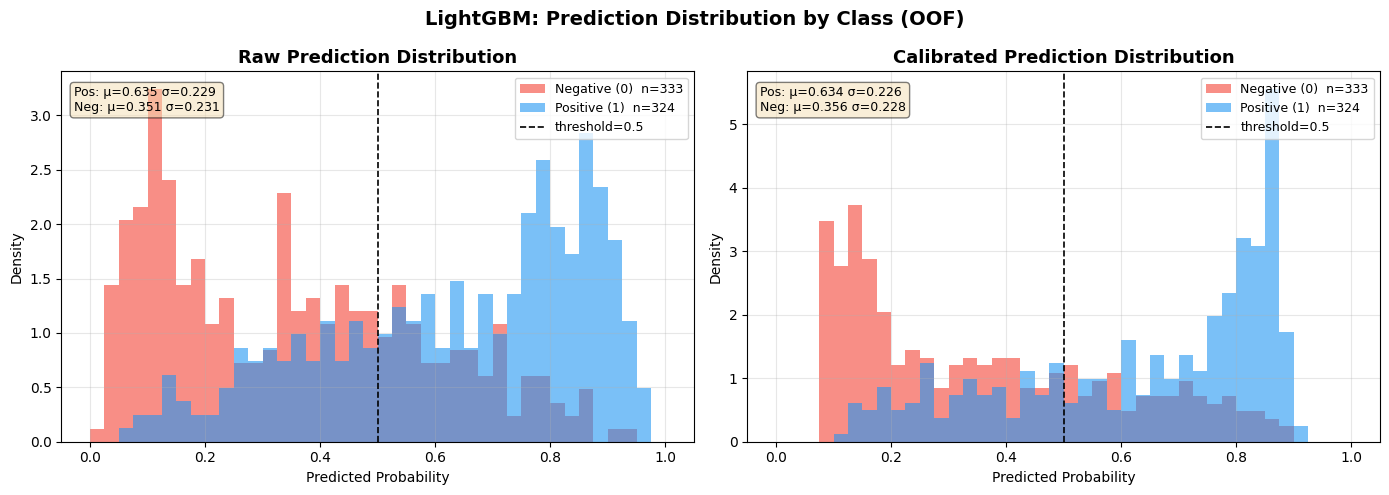

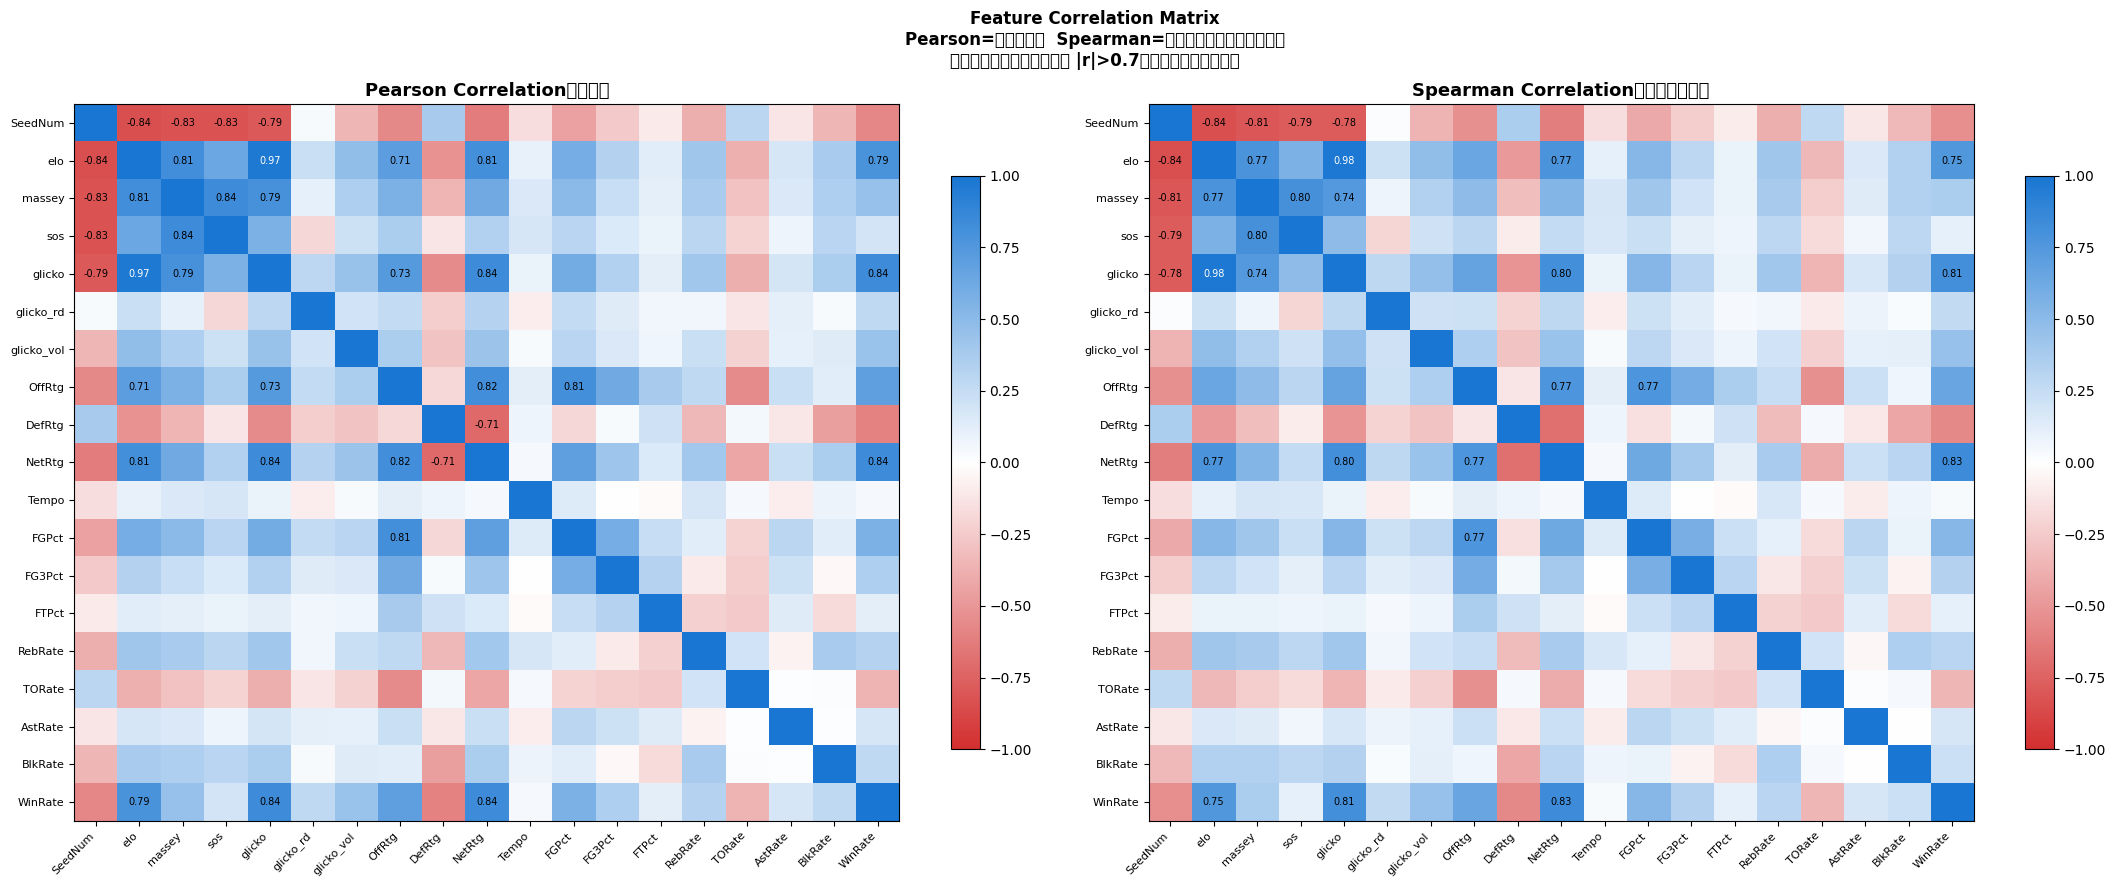

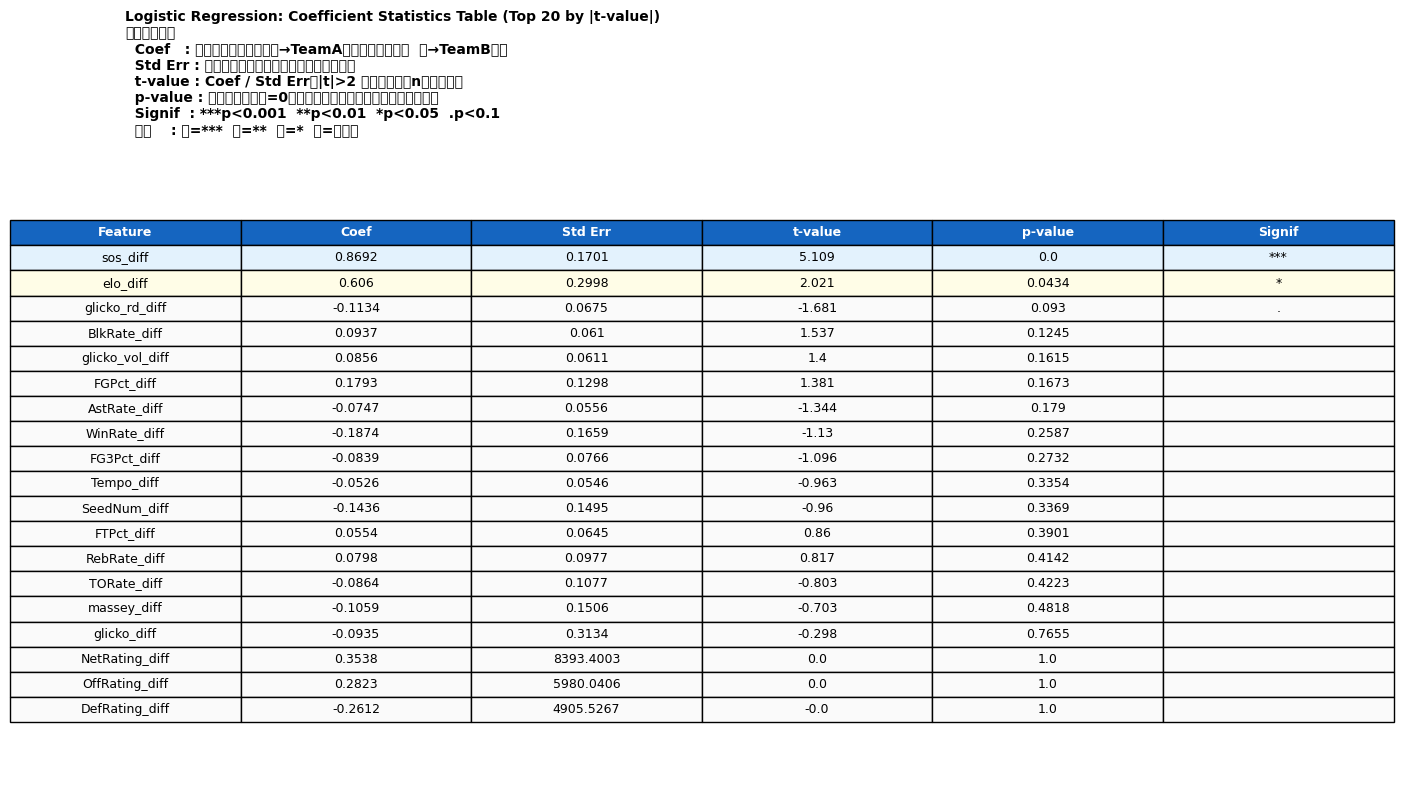


✅ 保存完了
   ../Data/mart/plots/01_pred_distribution.png
   ../Data/mart/plots/02_feature_correlation.png
   ../Data/mart/plots/03_lr_stats_table.png
   ../Data/mart/model_results.csv
   ../Data/mart/feature_importance.csv
   ../Data/mart/lr_stats_table.csv

【CV結果サマリー】
           brier         logloss             auc        
            mean     std    mean     std    mean     std
model                                                   
lgbm      0.1813  0.0157  0.5375  0.0389  0.8045  0.0367
logistic  0.1767  0.0158  0.5268  0.0493  0.8170  0.0325


In [6]:
"""
05_model.py
===========
INPUT : ../Data/mart/training_table.csv
OUTPUT: ../Data/mart/model_results.csv
        ../Data/mart/feature_importance.csv
        ../Data/mart/lr_stats_table.csv
        ../Data/mart/plots/ 以下に各グラフ

【分析内容】
1. 時系列CV（LightGBM + Logistic Regression）
2. LightGBM: 正例・負例別の予測値分布（Calibration後）
3. 特徴量間相関（Pearson + Spearman）
4. LR: 係数・標準誤差・t値・p値の統計テーブル
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import scipy.stats as stats
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score
from sklearn.calibration import calibration_curve

import lightgbm as lgb
import warnings
warnings.filterwarnings("ignore")

MART_DIR  = Path("../Data/mart")
PLOT_DIR  = MART_DIR / "plots"
MART_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)


# ══════════════════════════════════════════════════
# 0. データ読み込み
# ══════════════════════════════════════════════════
df = pd.read_csv(MART_DIR / "training_table.csv")
FEATURE_COLS = [c for c in df.columns if "_diff" in c]
TARGET = "target"
print(f"training_table: {df.shape}  特徴量数: {len(FEATURE_COLS)}")


# ══════════════════════════════════════════════════
# 1. 時系列CV
# ══════════════════════════════════════════════════
CV_FOLDS = [
    {"val": 2018, "train_end": 2017},
    {"val": 2019, "train_end": 2018},
    {"val": 2021, "train_end": 2019},
    {"val": 2022, "train_end": 2021},
    {"val": 2023, "train_end": 2022},
]

LGBM_PARAMS = {
    "objective": "binary", "metric": "binary_logloss",
    "learning_rate": 0.05, "num_leaves": 31, "max_depth": -1,
    "min_data_in_leaf": 20, "feature_fraction": 0.8,
    "bagging_fraction": 0.8, "bagging_freq": 5,
    "lambda_l1": 0.1, "lambda_l2": 0.1,
    "verbose": -1, "random_state": 42,
}


def platt_scale(pred_raw, y_true):
    """
    Platt Scaling を手動実装。
    CalibratedClassifierCV(cv="prefit") の代替。
    raw予測値（1次元）をロジスティック回帰でキャリブレーションする。
    """
    cal_lr = LogisticRegression(C=1e10, max_iter=1000, random_state=42)
    cal_lr.fit(pred_raw.reshape(-1, 1), y_true)
    pred_cal = cal_lr.predict_proba(pred_raw.reshape(-1, 1))[:, 1]
    return pred_cal


def run_cv_lgbm(df, feature_cols, folds):
    fold_results, oof_list, imp_list = [], [], []

    for fold in folds:
        val_s, train_end = fold["val"], fold["train_end"]
        tr = df[df["Season"] <= train_end]
        vl = df[df["Season"] == val_s]
        if len(vl) == 0:
            continue

        X_tr, y_tr = tr[feature_cols].fillna(0), tr[TARGET]
        X_vl, y_vl = vl[feature_cols].fillna(0), vl[TARGET]

        model = lgb.LGBMClassifier(**LGBM_PARAMS, n_estimators=500)
        model.fit(X_tr, y_tr,
                  eval_set=[(X_vl, y_vl)],
                  callbacks=[lgb.early_stopping(50, verbose=False),
                             lgb.log_evaluation(period=-1)])

        pred_raw = model.predict_proba(X_vl)[:, 1]

        # Platt Scaling（手動実装）
        # ※ CalibratedClassifierCV(cv="prefit") は sklearn 新バージョンで
        #   LightGBM のパラメータ検証エラーが起きるため手動実装に変更
        pred_cal = platt_scale(pred_raw, y_vl)

        brier = brier_score_loss(y_vl, pred_cal)
        ll    = log_loss(y_vl, pred_cal)
        auc   = roc_auc_score(y_vl, pred_cal)
        print(f"  [LGBM] val={val_s}: Brier={brier:.4f}  LogLoss={ll:.4f}  AUC={auc:.4f}")

        fold_results.append({"model": "lgbm", "val_season": val_s,
                              "brier": brier, "logloss": ll, "auc": auc})

        tmp = vl[["Season", "Gender", "TeamID_A", "TeamID_B", TARGET]].copy()
        tmp["pred_raw"] = pred_raw
        tmp["pred_cal"] = pred_cal
        oof_list.append(tmp)

        imp_list.append(pd.Series(model.feature_importances_, index=feature_cols))

    oof = pd.concat(oof_list, ignore_index=True)
    imp = pd.DataFrame(imp_list).mean().sort_values(ascending=False)
    res = pd.DataFrame(fold_results)
    print(f"  CV平均 Brier={res['brier'].mean():.4f} ±{res['brier'].std():.4f}")
    return res, oof, imp


def run_cv_lr(df, feature_cols, folds):
    fold_results, oof_list, coef_list = [], [], []

    for fold in folds:
        val_s, train_end = fold["val"], fold["train_end"]
        tr = df[df["Season"] <= train_end]
        vl = df[df["Season"] == val_s]
        if len(vl) == 0:
            continue

        X_tr, y_tr = tr[feature_cols].fillna(0), tr[TARGET]
        X_vl, y_vl = vl[feature_cols].fillna(0), vl[TARGET]

        scaler  = StandardScaler()
        X_tr_sc = scaler.fit_transform(X_tr)
        X_vl_sc = scaler.transform(X_vl)

        model = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
        model.fit(X_tr_sc, y_tr)
        pred = model.predict_proba(X_vl_sc)[:, 1]

        brier = brier_score_loss(y_vl, pred)
        ll    = log_loss(y_vl, pred)
        auc   = roc_auc_score(y_vl, pred)
        print(f"  [LR]   val={val_s}: Brier={brier:.4f}  LogLoss={ll:.4f}  AUC={auc:.4f}")

        fold_results.append({"model": "logistic", "val_season": val_s,
                              "brier": brier, "logloss": ll, "auc": auc})

        tmp = vl[["Season", "Gender", "TeamID_A", "TeamID_B", TARGET]].copy()
        tmp["pred"] = pred
        oof_list.append(tmp)
        coef_list.append(model.coef_[0])

    oof = pd.concat(oof_list, ignore_index=True)
    res = pd.DataFrame(fold_results)

    # ── LR統計テーブル（全データで再フィット） ──
    X_all = df[feature_cols].fillna(0)
    y_all = df[TARGET]
    scaler_all  = StandardScaler()
    X_all_sc    = scaler_all.fit_transform(X_all)
    model_all   = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
    model_all.fit(X_all_sc, y_all)

    coef    = model_all.coef_[0]
    pred_p  = model_all.predict_proba(X_all_sc)[:, 1]
    W       = np.diag(pred_p * (1 - pred_p))
    XtWX    = X_all_sc.T @ W @ X_all_sc
    try:
        cov     = np.linalg.inv(XtWX)
        se      = np.sqrt(np.diag(cov))
    except np.linalg.LinAlgError:
        se = np.full(len(coef), np.nan)

    t_val   = coef / (se + 1e-10)
    df_resid = len(y_all) - len(coef) - 1
    p_val   = 2 * (1 - stats.t.cdf(np.abs(t_val), df=df_resid))

    lr_stats = pd.DataFrame({
        "feature":  feature_cols,
        "coef":     coef.round(4),
        "std_err":  se.round(4),
        "t_value":  t_val.round(3),
        "p_value":  p_val.round(4),
        "signif":   ["***" if p < 0.001 else "**" if p < 0.01
                     else "*" if p < 0.05 else "." if p < 0.1
                     else "" for p in p_val],
    }).sort_values("t_value", key=abs, ascending=False)

    print(f"  CV平均 Brier={res['brier'].mean():.4f} ±{res['brier'].std():.4f}")
    return res, oof, lr_stats, scaler_all


# ── CV実行 ───────────────────────────────────────
print("\n" + "="*55)
print("【LightGBM】")
print("="*55)
lgbm_res, lgbm_oof, lgbm_imp = run_cv_lgbm(df, FEATURE_COLS, CV_FOLDS)

print("\n" + "="*55)
print("【Logistic Regression】")
print("="*55)
lr_res, lr_oof, lr_stats, lr_scaler = run_cv_lr(df, FEATURE_COLS, CV_FOLDS)


# ══════════════════════════════════════════════════
# 2. LightGBM: 正例・負例別の予測値分布
# ══════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in [
    (axes[0], "pred_raw", "Raw Prediction Distribution"),
    (axes[1], "pred_cal", "Calibrated Prediction Distribution"),
]:
    pos = lgbm_oof[lgbm_oof[TARGET] == 1][col]
    neg = lgbm_oof[lgbm_oof[TARGET] == 0][col]
    bins = np.linspace(0, 1, 41)

    ax.hist(neg, bins=bins, alpha=0.6, color="#F44336", label=f"Negative (0)  n={len(neg)}",
            density=True)
    ax.hist(pos, bins=bins, alpha=0.6, color="#2196F3", label=f"Positive (1)  n={len(pos)}",
            density=True)
    ax.axvline(0.5, color="black", linestyle="--", linewidth=1.2, label="threshold=0.5")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Predicted Probability")
    ax.set_ylabel("Density")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # 分布統計
    ax.text(0.02, 0.96,
            f"Pos: μ={pos.mean():.3f} σ={pos.std():.3f}\n"
            f"Neg: μ={neg.mean():.3f} σ={neg.std():.3f}",
            transform=ax.transAxes, va="top", fontsize=9,
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

plt.suptitle("LightGBM: Prediction Distribution by Class (OOF)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(PLOT_DIR / "01_pred_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


# ══════════════════════════════════════════════════
# 3. 特徴量間相関（Pearson + Spearman）
# ══════════════════════════════════════════════════
X_corr = df[FEATURE_COLS].fillna(0)

pearson_corr  = X_corr.corr(method="pearson")
spearman_corr = X_corr.corr(method="spearman")

# 短縮名（表示用）
short_names = {c: c.replace("_diff", "").replace("Rating", "Rtg") for c in FEATURE_COLS}
pearson_corr.index  = pearson_corr.index.map(short_names)
pearson_corr.columns = pearson_corr.columns.map(short_names)
spearman_corr.index  = spearman_corr.index.map(short_names)
spearman_corr.columns = spearman_corr.columns.map(short_names)

cmap = LinearSegmentedColormap.from_list("rg", ["#D32F2F", "white", "#1976D2"])

fig, axes = plt.subplots(1, 2, figsize=(22, 9))
for ax, corr, title in [
    (axes[0], pearson_corr,  "Pearson Correlation（線形）"),
    (axes[1], spearman_corr, "Spearman Correlation（非線形含む）"),
]:
    im = ax.imshow(corr.values, cmap=cmap, vmin=-1, vmax=1, aspect="auto")
    ax.set_xticks(range(len(corr.columns)))
    ax.set_yticks(range(len(corr.index)))
    ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(corr.index, fontsize=8)
    ax.set_title(title, fontsize=13, fontweight="bold")
    plt.colorbar(im, ax=ax, shrink=0.8)

    # 値を表示（絶対値が0.7以上のみ）
    for i in range(len(corr)):
        for j in range(len(corr.columns)):
            v = corr.values[i, j]
            if abs(v) > 0.7 and i != j:
                ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                        fontsize=7, color="white" if abs(v) > 0.85 else "black")

plt.suptitle("Feature Correlation Matrix\n"
             "Pearson=線形の強さ  Spearman=順位相関（非線形も捕捉）\n"
             "値が表示されているセルは |r|>0.7（多重共線性に注意）",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(PLOT_DIR / "02_feature_correlation.png", dpi=150, bbox_inches="tight")
plt.show()


# ══════════════════════════════════════════════════
# 4. LR 統計テーブルの可視化
# ══════════════════════════════════════════════════
top_lr = lr_stats.head(20).copy()

fig, ax = plt.subplots(figsize=(14, 8))
ax.axis("off")

col_labels = ["Feature", "Coef", "Std Err", "t-value", "p-value", "Signif"]
cell_data  = top_lr[["feature", "coef", "std_err", "t_value", "p_value", "signif"]].values.tolist()
cell_data  = [[str(v) for v in row] for row in cell_data]

table = ax.table(
    cellText=cell_data,
    colLabels=col_labels,
    loc="center",
    cellLoc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.5)

# ヘッダー色
for j in range(len(col_labels)):
    table[0, j].set_facecolor("#1565C0")
    table[0, j].set_text_props(color="white", fontweight="bold")

# 行色（有意水準で色分け）
for i, (_, row) in enumerate(top_lr.iterrows(), 1):
    p = row["p_value"]
    color = ("#E3F2FD" if p < 0.001 else
             "#E8F5E9" if p < 0.01 else
             "#FFFDE7" if p < 0.05 else
             "#FAFAFA")
    for j in range(len(col_labels)):
        table[i, j].set_facecolor(color)

ax.set_title(
    "Logistic Regression: Coefficient Statistics Table (Top 20 by |t-value|)\n"
    "【表の見方】\n"
    "  Coef   : 標準化された係数。正→TeamA有利に働く特徴量  負→TeamB有利\n"
    "  Std Err : 係数の標準誤差。小さいほど推定が安定\n"
    "  t-value : Coef / Std Err。|t|>2 で概ね有意（n数による）\n"
    "  p-value : 帰無仮説（係数=0）の棄却確率。小さいほど統計的に有意\n"
    "  Signif  : ***p<0.001  **p<0.01  *p<0.05  .p<0.1\n"
    "  行色    : 青=***  緑=**  黄=*  白=非有意",
    fontsize=10, fontweight="bold", pad=20, loc="left"
)

plt.tight_layout()
plt.savefig(PLOT_DIR / "03_lr_stats_table.png", dpi=150, bbox_inches="tight")
plt.show()


# ══════════════════════════════════════════════════
# 5. 保存
# ══════════════════════════════════════════════════
all_results = pd.concat([lgbm_res, lr_res], ignore_index=True)
all_results.to_csv(MART_DIR / "model_results.csv", index=False)

imp_df = pd.DataFrame({
    "feature":  FEATURE_COLS,
    "lgbm_imp": lgbm_imp.reindex(FEATURE_COLS).values,
}).sort_values("lgbm_imp", ascending=False)
imp_df.to_csv(MART_DIR / "feature_importance.csv", index=False)

lr_stats.to_csv(MART_DIR / "lr_stats_table.csv", index=False)

print("\n✅ 保存完了")
print(f"   {PLOT_DIR}/01_pred_distribution.png")
print(f"   {PLOT_DIR}/02_feature_correlation.png")
print(f"   {PLOT_DIR}/03_lr_stats_table.png")
print(f"   {MART_DIR}/model_results.csv")
print(f"   {MART_DIR}/feature_importance.csv")
print(f"   {MART_DIR}/lr_stats_table.csv")

print("\n" + "="*55)
print("【CV結果サマリー】")
print("="*55)
print(all_results.groupby("model")[["brier","logloss","auc"]].agg(["mean","std"]).round(4))